In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

print("Librarii incarcate cu succes!")

Librarii incarcate cu succes!


In [3]:
# Definesc numele fisierului CSV care contine datele despre creatorii de continut de pe YouTube
file_name = 'global_youtube_creator_data_large.csv'

# Citim doar 50.000 de randuri pentru a lucra rapid
try:
    df = pd.read_csv(file_name, nrows=5000)
    print(f"Succes! Am incarcat {df.shape[0]} randuri.")
except FileNotFoundError:
    print(f"Eroare: Nu am gasit fisierul {file_name}")

df.head()

Succes! Am incarcat 5000 randuri.


,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False


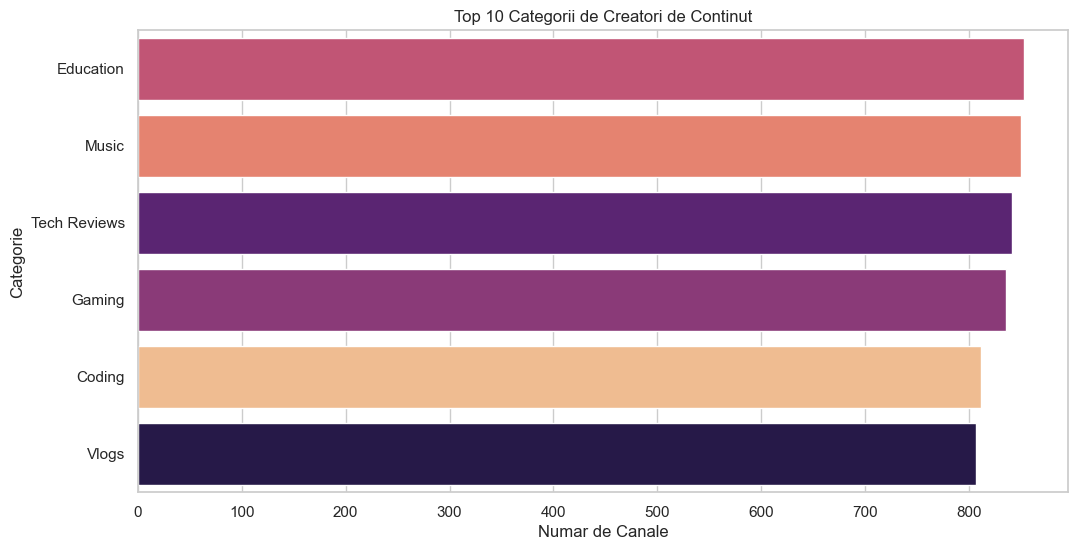

In [4]:
# 1. Setam dimensiunea ferestrei pentru grafic
plt.figure(figsize=(12, 6))

# 2. Cream graficul 
sns.countplot(
    data=df, 
    y='category', 
    order=df['category'].value_counts().index[:10], 
    hue='category', 
    palette='magma',
    legend=False
)

# 3. Adaugam elementele de text
plt.title('Top 10 Categorii de Creatori de Continut')
plt.xlabel('Numar de Canale')
plt.ylabel('Categorie')

plt.show()

In [4]:
#  DATA CLEANING 

# 1. Verificam daca avem valori null in dataset
print("Valori lipsa per coloana:")
print(df.isnull().sum())

# 2. Eliminam coloanele care nu ne ajuta la clasificare (ID-uri, link-uri, imagini)
# Adaptam lista de coloane in functie de ce are dataset-ul 
cols_to_drop = ['channel_id', 'channel_link', 'channel_motto', 'channel_motto_translated']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3. Stergem randurile care au valori nule in coloanele importante (ex: category)
df_clean = df_clean.dropna(subset=['category'])

# 4. Verificam daca s-au sters duplicatele
df_clean = df_clean.drop_duplicates()

print(f"\nCuratare finalizata!")
print(f"Randuri ramase: {df_clean.shape[0]}")
print(f"Coloane ramase: {df_clean.shape[1]}")

df_clean.head()

Valori lipsa per coloana:
timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

Curatare finalizata!
Randuri ramase: 5000
Coloane ramase: 12


,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False


Am creat cu succes o noua caracteristica: 'engagement_rate'!


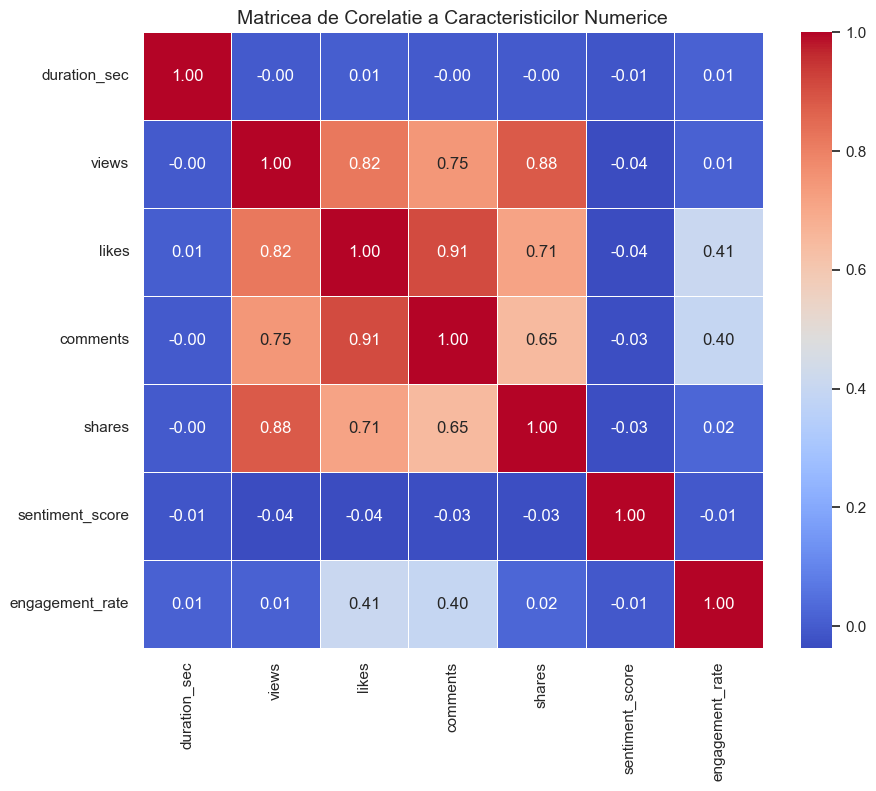

In [8]:
#  INGINERIA CARACTERISTICILOR SI CORELATII


# 1. FEATURE ENGINEERING 
# Cream 'engagement_rate' - total interactiuni raportate la numarul de vizualizari
# Punem (df_clean['views'] + 1) ca masura de siguranta matematica sa nu impartim la 0
df_clean['engagement_rate'] = (df_clean['likes'] + df_clean['comments'] + df_clean['shares']) / (df_clean['views'] + 1)

print("Am creat cu succes o noua caracteristica: 'engagement_rate'!")

# 2. SELECTAREA DATELOR NUMERICE
# Selectam automat doar coloanele care contin numere pentru a face matricea
coloane_numerice = df_clean.select_dtypes(include=['int64', 'float64'])

# Calculam matricea de corelatie
matrice_corelatie = coloane_numerice.corr()

# 3. VIZUALIZAREA CORELATIILOR (Heatmap)
plt.figure(figsize=(10, 8))

# Generam Heatmap-ul folosind seaborn
sns.heatmap(matrice_corelatie, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matricea de Corelatie a Caracteristicilor Numerice', fontsize=14)
plt.show()

In [7]:
print(df_clean.columns)

Index(['timestamp', 'video_id', 'category', 'language', 'region',
       'duration_sec', 'views', 'likes', 'comments', 'shares',
       'sentiment_score', 'ads_enabled'],
      dtype='str')


Pregatim modelul pentru a calcula importanta caracteristicilor...


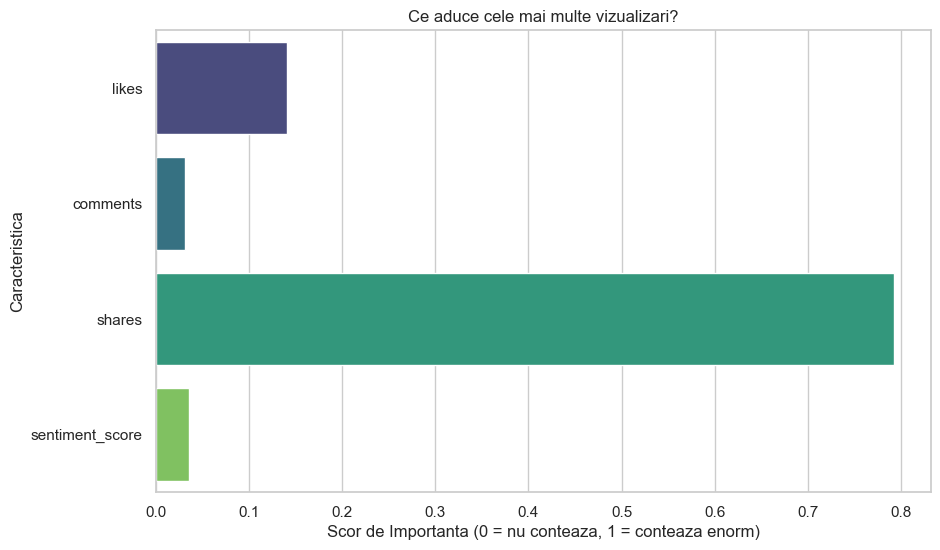

In [ ]:
# Importanta caracteristicilor 

from sklearn.ensemble import  RandomForestRegressor
print("Pregatim modelul pentru a calcula importanta caracteristicilor...")

# 1. Alegem coloanele pe care le analizam (X) si ce vrem sa prezicem (y = vizualizarile)
# Ne asiguram ca ignoram erorile de valori nule prin .fillna(0)
features = ['likes', 'comments', 'shares', 'sentiment_score']
X = df_clean[features].fillna(0) 
y = df_clean['views'].fillna(0)

# 2. Antrenam un model rapid (Random Forest)
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

# 3. Extragem rezultatele (cine este cel mai important?)
importante = model.feature_importances_

# 4. Desenam graficul
plt.figure(figsize=(10, 6))
sns.barplot(x=importante, y=features, hue=features, palette='viridis', legend=False)

plt.title('Ce aduce cele mai multe vizualizari?')
plt.xlabel('Scor de Importanta (0 = nu conteaza, 1 = conteaza enorm)')
plt.ylabel('Caracteristica')
plt.show()


In [ ]:
# Testarea Modelului (Tarin/Test Split)

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

print("Impartim datele in Antrenare (80%) si Testare (20%)...")

# 1. Definim datele
X = df_clean[['likes', 'comments', 'shares', 'sentiment_score']].fillna(0)
y = df_clean['views'].fillna(0)

# 2. Impartim datele aleatoriu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Antrenam modelul doar pe datele de antrenare (80%)
model_evaluare = RandomForestRegressor(n_estimators=50, random_state=42)
model_evaluare.fit(X_train, y_train)

# 4. Evaluam modelul pe datele de testare (cele 20%)
predictii = model_evaluare.predict(X_test)

# 5. Calculam nota (Scorul R-squared)
scor = r2_score(y_test, predictii)

print(f"Scorul de acuratete (R-squared) este: {scor:.2f}")
print("Nota: Un scor de 1.00 este perfect. Un scor peste 0.70 este chiar foarte bun!")

Impartim datele in Antrenare (80%) si Testare (20%)...
Scorul de acuratete (R-squared) este: 0.85
Nota: Un scor de 1.00 este perfect. Un scor peste 0.70 este considerat foarte bun!


Antrenarea si Compararea modelelor de ML

In [ ]:
# Import algoritmii si instrumentele de masurare pentru comparatie
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

print(" Se pregatesc datele si se antreneaza modelele...\n")

# 1. Definim datele noastre pentru antrenare si testare
features = ['likes', 'comments', 'shares', 'sentiment_score']
X = df[features].fillna(0)
y = df['views'].fillna(0)

# Impartim datele in 80% Antrenare / 20% Testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Cream lista cu cei 3 algoritmi
modele = {
    "Regresie Liniara": LinearRegression(),
    "Arbore de Decizie": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor()

}

rezultate_brute = []

# 3. Antrenam si testam fiecare algoritm pe rand
for nume, model in modele.items():
    model.fit(X_train, y_train)          # 
    predictii = model.predict(X_test)    # 
    
    # Calculam notele
    scor_r2 = r2_score(y_test, predictii)
    eroare_mae = mean_absolute_error(y_test, predictii)
    
    # Salvam rezultatele
    rezultate_brute.append({
        "Model": nume, 
        "Scor R2 (mai mare e mai bun)": round(scor_r2, 4), 
        "Eroare MAE (mai mic e mai bun)": round(eroare_mae, 2)
    })
    print(f"✅ {nume} a terminat antrenamentul!")

# 4. Cream tabelul comparativ final
df_rezultate = pd.DataFrame(rezultate_brute).sort_values(by="Scor R2 (mai mare e mai bun)", ascending=False)

print("\n  Tabel cu rezultate brute  ")
display(df_rezultate)

 Pregatim datele si antrenam modelele...

✅ Regresie Liniara a terminat antrenamentul!
✅ Arbore de Decizie a terminat antrenamentul!
✅ Random Forest a terminat antrenamentul!
✅ Gradient Boosting a terminat antrenamentul!
✅ K-Nearest Neighbors a terminat antrenamentul!

  Tabel cu rezultate brute  


,Model,Scor R2 (mai mare e mai bun),Eroare MAE (mai mic e mai bun)
3,Gradient Boosting,0.8614,2277.30
2,Random Forest,0.8524,2371.16
0,Regresie Liniara,0.8454,2549.02
4,K-Nearest Neighbors,0.8150,2553.21
1,Arbore de Decizie,0.7461,2961.62
